# Asset Allocation & Portfolio Optimization

## Objective
Construct an optimal multi-asset portfolio using mean-variance optimization.  
This project simulates 10,000 random portfolios and identifies the efficient frontier —  
the set of portfolios that maximize return for a given level of risk.

## Assets
| Ticker | Asset Class |
|--------|-------------|
| SPY | US Equity |
| TLT | US Long-Term Bond |
| GLD | Gold |
| VNQ | Real Estate |
| EFA | International Equity |

## Key Concepts
- **Efficient Frontier**: the boundary of optimal portfolios in risk-return space
- **Sharpe Ratio**: excess return per unit of risk `(Return - Rf) / Volatility`
- **Diversification**: assets with low correlation reduce overall portfolio risk

## Results
- **Max Sharpe Ratio Portfolio**: concentrated in US Equity + Gold — highest risk-adjusted return
- **Min Volatility Portfolio**: concentrated in Long-Term Bonds — lowest risk, suitable for conservative mandates such as pension funds

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
import time
warnings.filterwarnings('ignore')

In [15]:
np.random.seed(42)
n_days = 1259  

annual_returns = np.array([0.12, 0.03, 0.08, 0.09, 0.07])  # SPY TLT GLD VNQ EFA
annual_vols    = np.array([0.18, 0.14, 0.16, 0.20, 0.17])

corr = np.array([
    [ 1.00, -0.30,  0.05,  0.70,  0.85],
    [-0.30,  1.00,  0.10, -0.20, -0.25],
    [ 0.05,  0.10,  1.00,  0.05,  0.05],
    [ 0.70, -0.20,  0.05,  1.00,  0.65],
    [ 0.85, -0.25,  0.05,  0.65,  1.00]
])

daily_vols = annual_vols / np.sqrt(252)
cov = np.outer(daily_vols, daily_vols) * corr

daily_mean = annual_returns / 252
returns = pd.DataFrame(
    np.random.multivariate_normal(daily_mean, cov, n_days),
    columns=['SPY', 'TLT', 'GLD', 'VNQ', 'EFA']
)

print("Data shape:", returns.shape)
print("\nAnnualized mean returns:")
print((returns.mean() * 252).round(4))

Data shape: (1259, 5)

Annualized mean returns:
SPY    0.1420
TLT    0.0222
GLD    0.1162
VNQ    0.1301
EFA    0.0348
dtype: float64


In [14]:
n_portfolios = 10000

results = np.zeros((3, n_portfolios)) 
weights_record = np.zeros((n_portfolios, 5))

cov_matrix = returns.cov() * 252  
mean_returns = returns.mean() * 252  

rf = 0.04

for i in range(n_portfolios):
    w = np.random.random(5)
    w = w / np.sum(w)
    
    port_return = np.dot(w, mean_returns)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    sharpe = (port_return - rf) / port_vol
    
    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = sharpe
    weights_record[i] = w

print("Simulation complete. Total portfolios generated:", n_portfolios)

Simulation complete. Total portfolios generated: 10000


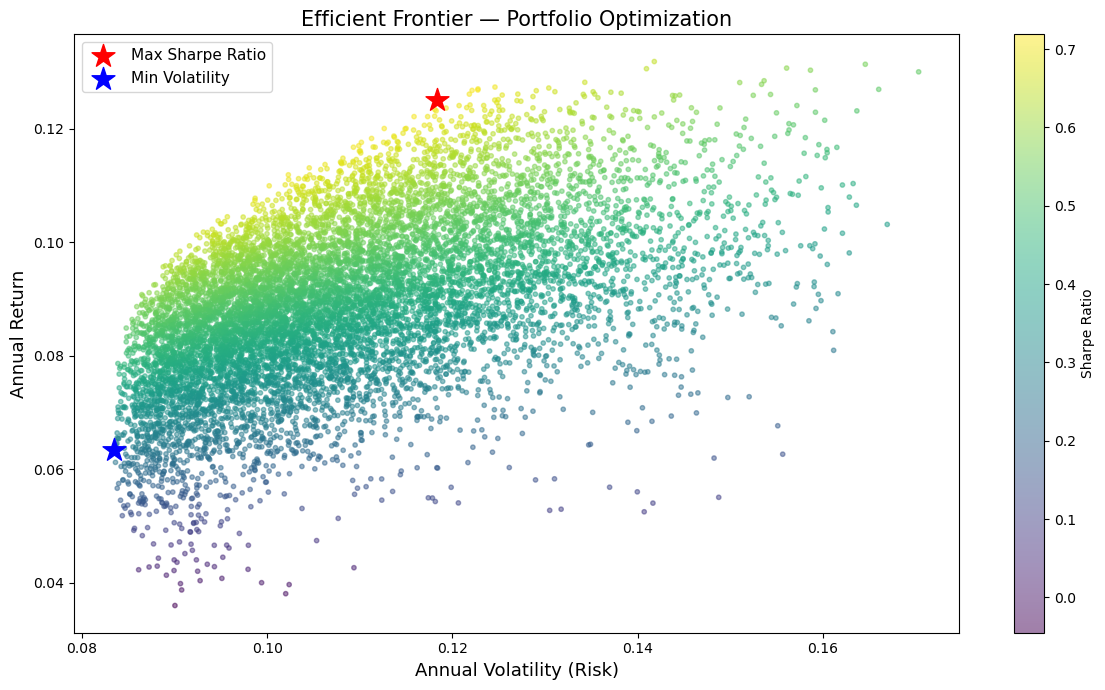


Max Sharpe Ratio Portfolio Weights:
  SPY: 42.06%
  TLT: 3.43%
  GLD: 43.09%
  VNQ: 11.01%
  EFA: 0.41%

Min Volatility Portfolio Weights:
  SPY: 9.71%
  TLT: 44.12%
  GLD: 20.03%
  VNQ: 7.85%
  EFA: 18.29%


In [13]:
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[1])

max_sharpe_weights = weights_record[max_sharpe_idx]
min_vol_weights = weights_record[min_vol_idx]

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    results[1], results[0],
    c=results[2], cmap='viridis',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(
    results[1, max_sharpe_idx], results[0, max_sharpe_idx],
    marker='*', color='red', s=300, label='Max Sharpe Ratio'
)

plt.scatter(
    results[1, min_vol_idx], results[0, min_vol_idx],
    marker='*', color='blue', s=300, label='Min Volatility'
)

plt.xlabel('Annual Volatility (Risk)', fontsize=13)
plt.ylabel('Annual Return', fontsize=13)
plt.title('Efficient Frontier — Portfolio Optimization', fontsize=15)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150)
plt.show()

tickers = ['SPY', 'TLT', 'GLD', 'VNQ', 'EFA']

print("\nMax Sharpe Ratio Portfolio Weights:")
for t, w in zip(tickers, max_sharpe_weights):
    print(f"  {t}: {w:.2%}")

print("\nMin Volatility Portfolio Weights:")
for t, w in zip(tickers, min_vol_weights):
    print(f"  {t}: {w:.2%}")